# 🏏 IPL — Batter vs Spin Bowling · Prediction Model v4

A clean, production-ready notebook that trains the full v3 model pipeline
and exports all artefacts used by `app.py`.

| Step | What happens |
|------|-------------|
| 1 | Imports |
| 2 | Load data (CSV + optional Cricsheet JSON) |
| 3 | Clean & standardise |
| 4 | Identify spin deliveries |
| 5 | Feature engineering (batter, venue, form, ball-level) |
| 6 | KMeans batter clustering |
| 7 | Build model dataset |
| 8 | Train & compare RF / XGBoost / LightGBM |
| 9 | Hyperparameter tuning (best model) |
| 10 | SHAP explainability |
| 11 | Validation |
| 12 | Prediction functions |
| 13 | Monte Carlo simulation |
| 14 | Full-match prediction |
| 15 | Save all artefacts |

**Files required in the same folder:**

| File | Required |
|------|----------|
| `Ball_By_Ball_Match_Data.csv` | ✅ |
| `2026_players_details.csv` | ✅ |
| `Match_Info.csv` | ✅ |
| Cricsheet JSON folder | optional |

**Files produced (all used by `app.py`):**

`model_runs.pkl` · `model_wicket.pkl` · `encoder_spin.pkl` · `encoder_phase.pkl`
· `model_kmeans.pkl` · `scaler_cluster.pkl` · `batter_features.csv`
· `venue_features.csv` · `form_features.csv`


## 📦 Step 1 — Imports

In [ ]:
import json, glob, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.cluster import KMeans
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.metrics import (mean_absolute_error, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

import xgboost as xgb
import lightgbm as lgb
import shap

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print(f'✅ Libraries loaded  |  XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  SHAP {shap.__version__}')


ModuleNotFoundError: No module named 'xgboost'

## 📂 Step 2 — Config & Load Data

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_FOLDER = '.'                   # folder containing this notebook + CSVs
JSON_FOLDER = '../json/ipl_match'   # Cricsheet JSON folder (leave as-is if not using)
SKIP_JSON   = {'teams_info.json'}   # JSON files to ignore

SPIN_TYPES = [
    'right-arm offbreak',
    'legbreak',
    'legbreak googly',
    'slow left-arm orthodox',
    'left-arm wrist-spin',
]

TEAM_ALIAS = {
    'Kings XI Punjab'             : 'Punjab Kings',
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
}

# ── Load required CSVs ────────────────────────────────────────────────────────
# Use cricsheet_balls_parsed.csv (has venue + season built in — no Match_Info needed)
_raw    = pd.read_csv(os.path.join(DATA_FOLDER, 'cricsheet_balls_parsed.csv'), low_memory=False)
players = pd.read_csv(os.path.join(DATA_FOLDER, '2026_players_details.csv'))

# ── Rename cricsheet columns → model column names ─────────────────────────────
balls = _raw.rename(columns={
    'match_id'    : 'ID',
    'innings'     : 'Innings',
    'over'        : 'Overs',
    'ball_in_over': 'BallNumber',
    'batter'      : 'Batter',
    'bowler'      : 'Bowler',
    'runs_batter' : 'BatsmanRun',
    'runs_extras' : 'ExtrasRun',
    'runs_total'  : 'TotalRun',
    'is_wicket'   : 'IsWicketDelivery',
    'wicket_kind' : 'Kind',
    'batting_team': 'BattingTeam',
})

# ── Derive ExtraType from wides/noballs columns ───────────────────────────────
def get_extra_type(row):
    if row.get('wides', 0) > 0:   return 'wides'
    if row.get('noballs', 0) > 0:  return 'noballs'
    return None
balls['ExtraType'] = balls.apply(get_extra_type, axis=1)

# ── venue and season already present in cricsheet ────────────────────────────
# (no merge with Match_Info needed)

print(f'cricsheet_balls_parsed : {len(balls):,} rows')
print(f'Players                : {len(players):,} rows')
print(f'Seasons                : {sorted(balls["season"].dropna().unique())}')
print(f'Venues (raw)           : {balls["venue"].nunique()} unique')


cricsheet_balls_parsed : 278,205 rows
Players                : 261 rows
Seasons                : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']
Venues (raw)           : 40 unique


In [ ]:
# ── Optional: Load Cricsheet JSON files ───────────────────────────────────────
def parse_cricsheet(filepath):
    """Parse one Cricsheet JSON file → list of delivery dicts."""
    match_id = os.path.splitext(os.path.basename(filepath))[0]
    rows = []
    try:
        with open(filepath, encoding='utf-8') as f:
            m = json.load(f)
    except Exception as e:
        print(f'  ⚠ Could not read {filepath}: {e}')
        return rows

    info  = m.get('info', {})
    teams = info.get('teams', [])

    for inn_idx, inn in enumerate(m.get('innings', [])):
        bt = inn.get('team', '')
        for od in inn.get('overs', []):
            ov = od.get('over', -1)
            for bn, ball in enumerate(od.get('deliveries', [])):
                extras = ball.get('extras', {})
                runs   = ball.get('runs', {})
                wkts   = ball.get('wickets', [])
                rows.append({
                    'ID'              : match_id,
                    'Innings'         : inn_idx + 1,
                    'Overs'           : ov,
                    'BallNumber'      : bn + 1,
                    'Batter'          : ball.get('batter', ''),
                    'Bowler'          : ball.get('bowler', ''),
                    'BatsmanRun'      : runs.get('batter', 0),
                    'ExtrasRun'       : runs.get('extras', 0),
                    'TotalRun'        : runs.get('total', 0),
                    'IsWicketDelivery': int(bool(wkts)),
                    'Kind'            : wkts[0].get('kind', '') if wkts else '',
                    'ExtraType'       : ('wides'   if 'wides'   in extras else
                                        'noballs' if 'noballs' in extras else np.nan),
                    'BattingTeam'     : bt,
                    'venue'           : info.get('venue', ''),
                })
    return rows


json_files = [
    f for f in sorted(glob.glob(os.path.join(JSON_FOLDER, '*.json')))
    if os.path.basename(f) not in SKIP_JSON
]
print(f'Found {len(json_files)} Cricsheet JSON files', end='')

all_json_rows = []
for i, fp in enumerate(json_files):
    all_json_rows.extend(parse_cricsheet(fp))
    if (i + 1) % 200 == 0 or (i + 1) == len(json_files):
        print(f'  Parsed {i+1}/{len(json_files)} — {len(all_json_rows):,} deliveries', end='\r')

json_balls = pd.DataFrame(all_json_rows) if all_json_rows else pd.DataFrame()
print(f'\nDone. JSON deliveries: {len(json_balls):,}')


  Parsed 1209/1209 — 287,513 deliveries 200/1209 — 47,542 deliveries
Done. JSON deliveries: 287,513


## 🧹 Step 3 — Clean & Merge

In [ ]:
COMMON_COLS = ['ID','Innings','Overs','BallNumber','Batter','Bowler',
               'BatsmanRun','ExtrasRun','TotalRun','IsWicketDelivery',
               'Kind','ExtraType','BattingTeam','season','venue']

# cricsheet_balls_parsed already has venue + season built in — no JSON or Match_Info needed
all_balls = balls[COMMON_COLS].copy()

# Standardise team names and fix player data
all_balls['BattingTeam']     = all_balls['BattingTeam'].replace(TEAM_ALIAS)
players['longBowlingStyles'] = players['longBowlingStyles'].replace('Na', np.nan)

# Remove duplicates
dupes = all_balls.duplicated().sum()
all_balls.drop_duplicates(inplace=True)

# Fix slash-format seasons: '2020/21' → 2020, '2009/10' → 2009
all_balls['season'] = all_balls['season'].astype(str).str.split('/').str[0].astype(int)

print(f'Total deliveries : {len(all_balls):,}  ({dupes} duplicates removed)')
print(f'Seasons          : {sorted(all_balls["season"].dropna().unique())}')
print(f'Missing values   :\n{all_balls.isnull().sum()[all_balls.isnull().sum() > 0]}')

Total deliveries : 278,205  (0 duplicates removed)
Seasons          : [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Missing values   :
Kind         264382
ExtraType    267962
dtype: int64


## 🌀 Step 4 — Identify Spin Deliveries

In [ ]:
# Build name → spin-type lookup from players CSV
spin_map = {
    row['Name']: row['longBowlingStyles']
    for _, row in players.iterrows()
    if row['longBowlingStyles'] in SPIN_TYPES
}
print(f'Spin bowlers identified : {len(spin_map)}')
print(players[players['longBowlingStyles'].isin(SPIN_TYPES)]['longBowlingStyles'].value_counts())

# Remove illegal deliveries (wides, no-balls — batter doesn't face them)
legal = all_balls[~all_balls['ExtraType'].isin(['wides', 'noballs'])].copy()

# Filter to spin deliveries only
spin             = legal[legal['Bowler'].isin(spin_map)].copy()
spin['spin_type'] = spin['Bowler'].map(spin_map)
spin['phase']     = pd.cut(
    spin['Overs'], bins=[-1, 5, 14, 19],
    labels=['powerplay', 'middle', 'death']
)

print(f'\nLegal deliveries      : {len(legal):,}')
print(f'Spin deliveries       : {len(spin):,}  ({len(spin)/len(legal)*100:.1f}%)')
print(f'Unique batters vs spin: {spin["Batter"].nunique()}')


Spin bowlers identified : 116
longBowlingStyles
right-arm offbreak        55
slow left-arm orthodox    26
legbreak                  20
legbreak googly           13
left-arm wrist-spin        2
Name: count, dtype: int64

Legal deliveries      : 267,962
Spin deliveries       : 58,243  (21.7%)
Unique batters vs spin: 534


## ⚙️ Step 5 — Feature Engineering

Four feature sets are built:
1. **Batter career stats** vs spin (SR, avg, dot%, boundary%, wicket rate …)
2. **Venue spin stats** (how spin-friendly is each ground?)
3. **Recent form** (rolling SR across last 5 innings vs spin)
4. **Ball-level context** (position in over, interaction terms)


In [ ]:
# ── 5a: Batter career stats vs ALL spin combined (clustering + fallback) ──
def build_batter_features(spin_df):
    bf = spin_df.groupby('Batter').agg(
        total_balls      = ('BatsmanRun', 'count'),
        total_runs       = ('BatsmanRun', 'sum'),
        dismissals       = ('IsWicketDelivery', 'sum'),
        dots             = ('BatsmanRun', lambda x: (x == 0).sum()),
        fours            = ('BatsmanRun', lambda x: (x == 4).sum()),
        sixes            = ('BatsmanRun', lambda x: (x == 6).sum()),
        ones             = ('BatsmanRun', lambda x: (x == 1).sum()),
        twos             = ('BatsmanRun', lambda x: (x == 2).sum()),
    ).reset_index()
    bf['sr']           = bf['total_runs'] / bf['total_balls'] * 100
    bf['avg']          = (bf['total_runs'] / bf['dismissals'].replace(0, np.nan)).fillna(bf['total_runs'])
    bf['dot_pct']      = bf['dots']  / bf['total_balls'] * 100
    bf['boundary_pct'] = (bf['fours'] + bf['sixes']) / bf['total_balls'] * 100
    bf['six_pct']      = bf['sixes'] / bf['total_balls'] * 100
    bf['wkt_rate']     = bf['dismissals'] / bf['total_balls'] * 100
    bf['rotation_pct'] = (bf['ones'] + bf['twos']) / bf['total_balls'] * 100
    return bf

batter_feats = build_batter_features(spin)
print(f'Career batter features (all spin): {batter_feats.shape}')

# ── 5a-2: Per-spin-type batter stats — THE KEY FIX ──────────────────────────
# Each row = one batter x one spin type they have faced.
# Step 7 will join model_df on (Batter, spin_type) so sr/dot_pct/wkt_rate
# genuinely differ per spin type -> genuinely different predictions.
def build_batter_features_by_spin(spin_df):
    bf = spin_df.groupby(['Batter', 'spin_type']).agg(
        total_balls      = ('BatsmanRun', 'count'),
        total_runs       = ('BatsmanRun', 'sum'),
        dismissals       = ('IsWicketDelivery', 'sum'),
        dots             = ('BatsmanRun', lambda x: (x == 0).sum()),
        fours            = ('BatsmanRun', lambda x: (x == 4).sum()),
        sixes            = ('BatsmanRun', lambda x: (x == 6).sum()),
        ones             = ('BatsmanRun', lambda x: (x == 1).sum()),
        twos             = ('BatsmanRun', lambda x: (x == 2).sum()),
    ).reset_index()
    bf['sr']           = bf['total_runs'] / bf['total_balls'] * 100
    bf['avg']          = (bf['total_runs'] / bf['dismissals'].replace(0, np.nan)).fillna(bf['total_runs'])
    bf['dot_pct']      = bf['dots']  / bf['total_balls'] * 100
    bf['boundary_pct'] = (bf['fours'] + bf['sixes']) / bf['total_balls'] * 100
    bf['six_pct']      = bf['sixes'] / bf['total_balls'] * 100
    bf['wkt_rate']     = bf['dismissals'] / bf['total_balls'] * 100
    bf['rotation_pct'] = (bf['ones'] + bf['twos']) / bf['total_balls'] * 100
    return bf

batter_spin_feats = build_batter_features_by_spin(spin)
print(f'Per-spin batter features          : {batter_spin_feats.shape}')
print(f'Batter x spin_type pairs          : {len(batter_spin_feats)}')
print(f'\nSpin type distribution:')
print(batter_spin_feats.groupby('spin_type')['total_balls'].agg(['count','sum']).rename(
    columns={'count': 'batters', 'sum': 'total_balls'}))


Batter features : (534, 16)


,Batter,total_balls,sr,avg,dot_pct,boundary_pct,wkt_rate
446,SP Narine,238,197.48,19.58,35.29,31.93,10.08
52,Abhishek Sharma,324,187.04,33.67,25.62,24.69,5.56
57,Aniket Verma,60,183.33,27.50,33.33,25.00,6.67
360,Priyansh Arya,59,179.66,26.50,27.12,23.73,6.78
165,H Klaasen,372,179.57,55.67,22.58,22.04,3.23
500,V Sehwag,137,177.37,34.71,21.90,23.36,5.11
343,PD Salt,124,174.19,21.60,31.45,29.84,8.06
313,N Pooran,497,171.23,53.19,33.40,22.54,3.22


In [ ]:
# ── 5b: Venue spin features ──────────────────────────────────────────────────
def build_venue_features(spin_df, min_deliveries=50):
    """
    Per-venue spin stats:
    - venue_spin_wkt_rate : how often spinners take wickets here
    - venue_spin_economy  : average runs per ball off spin here
    High wkt_rate + low economy = spin-friendly venue.
    """
    vf = spin_df.groupby('venue').agg(
        venue_spin_wkt_rate = ('IsWicketDelivery', 'mean'),
        venue_spin_economy  = ('BatsmanRun', 'mean'),
        venue_deliveries    = ('BatsmanRun', 'count'),
    ).reset_index()
    return vf[vf['venue_deliveries'] >= min_deliveries].drop(columns='venue_deliveries').reset_index(drop=True)


# ── Clean duplicate venue names BEFORE building features ─────────────────────
venue_clean = {
    'Wankhede Stadium, Mumbai':                                              'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru':                                      'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium':                                                 'M Chinnaswamy Stadium',
    'Eden Gardens, Kolkata':                                                 'Eden Gardens',
    'MA Chidambaram Stadium, Chepauk':                                       'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai':                              'MA Chidambaram Stadium',
    'Arun Jaitley Stadium, Delhi':                                           'Arun Jaitley Stadium',
    'Rajiv Gandhi International Stadium, Uppal':                             'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':                  'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':                  'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh':      'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association Stadium, Mohali':                            'Punjab Cricket Association IS Bindra Stadium',
    'Narendra Modi Stadium, Ahmedabad':                                      'Narendra Modi Stadium',
    'Maharashtra Cricket Association Stadium, Pune':                         'Maharashtra Cricket Association Stadium',
    'Sawai Mansingh Stadium, Jaipur':                                        'Sawai Mansingh Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':              'Himachal Pradesh Cricket Association Stadium',
    'Brabourne Stadium, Mumbai':                                             'Brabourne Stadium',
    'Barsapara Cricket Stadium, Guwahati':                                   'Barsapara Cricket Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow':'Ekana Cricket Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur':    'New Chandigarh Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh':'New Chandigarh Stadium',
    'Dr DY Patil Sports Academy, Mumbai':                                    'Dr DY Patil Sports Academy',
}

spin['venue'] = spin['venue'].replace(venue_clean)
print(f'Unique venues after cleaning: {spin["venue"].nunique()}')

venue_feats = build_venue_features(spin)
print(f'Venues with ≥50 spin deliveries: {len(venue_feats)}')
venue_feats.sort_values('venue_spin_wkt_rate', ascending=False).head(5)

Unique venues after cleaning: 40
Venues with ≥50 spin deliveries: 37


,venue,venue_spin_wkt_rate,venue_spin_economy
4,De Beers Diamond Oval,0.104651,1.046512
34,SuperSport Park,0.075829,1.222749
22,New Chandigarh Stadium,0.060683,1.201011
15,JSCA International Stadium Complex,0.060209,1.060209
7,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,0.059925,1.539326


In [ ]:
# ── 5c: Recent form — rolling SR across last 5 innings vs spin ───────────────
def build_recent_form(spin_df):
    """
    For each batter, compute their rolling average SR across
    their last 5 innings vs spin (shift(1) so current innings is not leaked).
    """
    inn_agg = (
        spin_df.sort_values(['Batter', 'ID', 'Innings'])
        .groupby(['Batter', 'ID', 'Innings'])
        .agg(inn_runs=('BatsmanRun', 'sum'), inn_balls=('BatsmanRun', 'count'))
        .reset_index()
    )
    inn_agg['inn_sr'] = inn_agg['inn_runs'] / inn_agg['inn_balls'] * 100

    inn_agg = inn_agg.sort_values(['Batter', 'ID'])
    inn_agg['form_sr_last5'] = (
        inn_agg.groupby('Batter')['inn_sr']
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

    form = inn_agg.groupby('Batter')['form_sr_last5'].last().reset_index()
    return form


form_feats = build_recent_form(spin)
print(f'Recent form computed for {len(form_feats)} batters')
form_feats.sort_values('form_sr_last5', ascending=False).head(5)


Recent form computed for 534 batters


,Batter,form_sr_last5
66,Avesh Khan,450.000000
497,Urvil Patel,425.000000
280,MJ McClenaghan,383.333333
388,RJ Peterson,375.000000
202,JJ Roy,241.415205


In [ ]:
# ── 5d: Ball-level derived features ──────────────────────────────────────────
spin['ball_in_over_norm'] = spin['BallNumber'] / 6
spin['is_last_ball']      = (spin['BallNumber'] == 6).astype(int)
spin['over_x_ball']       = spin['Overs'] * spin['BallNumber']
spin['is_death_last']     = ((spin['Overs'] >= 17) & (spin['BallNumber'] >= 5)).astype(int)

print('Ball-level features added: ball_in_over_norm, is_last_ball, over_x_ball, is_death_last')


Ball-level features added: ball_in_over_norm, is_last_ball, over_x_ball, is_death_last


## 🔵 Step 6 — KMeans Batter Clustering

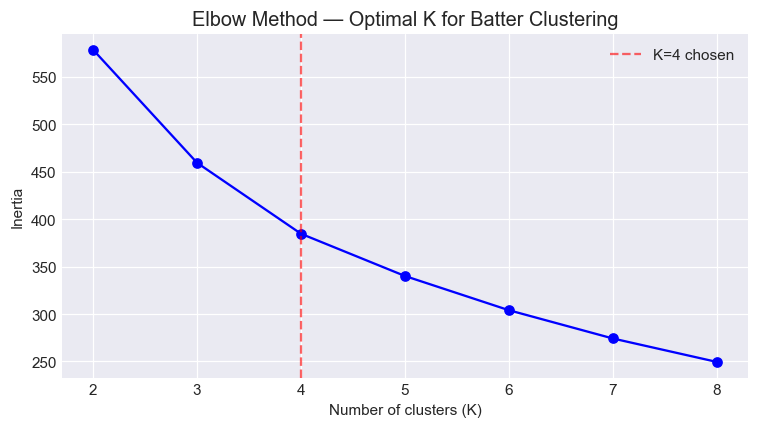

In [ ]:
CLUSTER_FEATURES = ['sr', 'dot_pct', 'boundary_pct', 'wkt_rate']
CLUSTER_NAMES    = {
    0: 'Aggressive Attacker',
    1: 'Steady Accumulator',
    2: 'Spin Vulnerable',
    3: 'Balanced Performer',
}

# Only cluster batters with ≥30 balls vs spin
bf_q      = batter_feats[batter_feats['total_balls'] >= 30].copy()
scaler    = StandardScaler()
X_cluster = scaler.fit_transform(bf_q[CLUSTER_FEATURES].fillna(0))

# Elbow method to confirm K=4
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-')
ax.axvline(4, color='red', linestyle='--', alpha=0.6, label='K=4 chosen')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal K for Batter Clustering')
ax.legend()
plt.tight_layout()
plt.show()


Cluster Centroids:
             sr  dot_pct  boundary_pct  wkt_rate
cluster                                         
0         83.29    47.36          6.75      5.50
1        113.52    41.91         12.86      8.46
2        169.48    30.22         23.42      5.69
3        127.63    32.96         13.84      3.97

Batters per cluster: {3: 114, 1: 44, 0: 44, 2: 29}


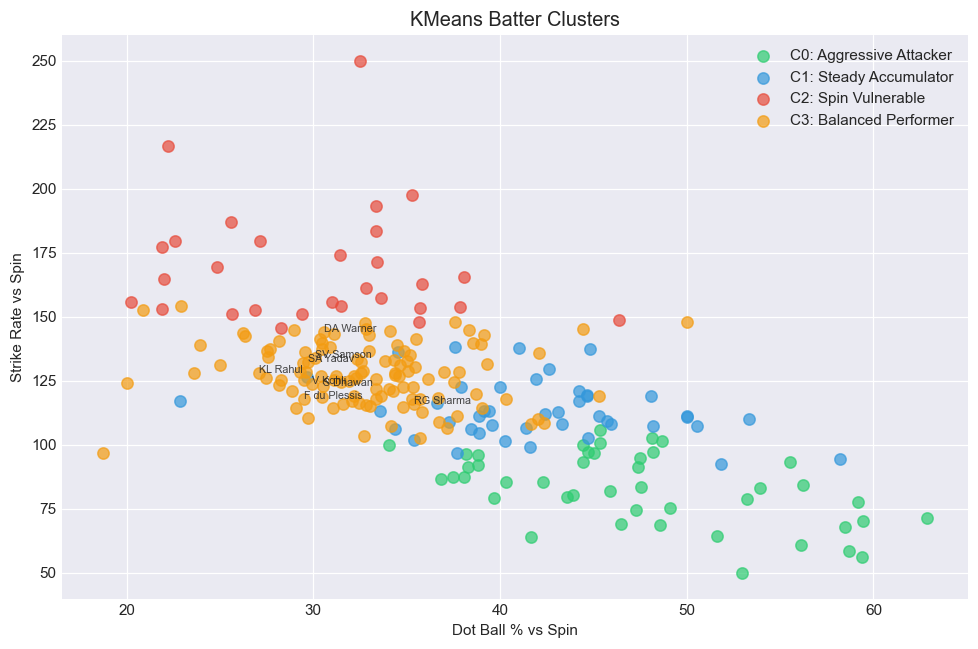


Cluster labels added to batter_feats ✅


In [ ]:
# Fit final KMeans with K=4
N_CLUSTERS   = 4
kmeans       = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
bf_q['cluster'] = kmeans.fit_predict(X_cluster)

cluster_summary = bf_q.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
print('Cluster Centroids:')
print(cluster_summary)
print(f'\nBatters per cluster: {bf_q["cluster"].value_counts().to_dict()}')

# Scatter plot
fig, ax = plt.subplots(figsize=(9, 6))
colors   = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for c in range(N_CLUSTERS):
    mask = bf_q['cluster'] == c
    ax.scatter(bf_q[mask]['dot_pct'], bf_q[mask]['sr'],
               s=55, alpha=0.7, color=colors[c],
               label=f'C{c}: {CLUSTER_NAMES[c]}')
ax.set_xlabel('Dot Ball % vs Spin')
ax.set_ylabel('Strike Rate vs Spin')
ax.set_title('KMeans Batter Clusters')
ax.legend()
for _, row in bf_q.nlargest(8, 'total_balls').iterrows():
    ax.annotate(row['Batter'], (row['dot_pct'], row['sr']), fontsize=7, alpha=0.85)
plt.tight_layout()
plt.show()

# Merge cluster labels back into batter_feats
batter_feats = batter_feats.merge(bf_q[['Batter', 'cluster']], on='Batter', how='left')
batter_feats['cluster'] = batter_feats['cluster'].fillna(-1).astype(int)
print('\nCluster labels added to batter_feats ✅')


## 📊 Step 7 — Build Model Dataset

In [ ]:
# Encode categorical features
le_spin  = LabelEncoder()
le_phase = LabelEncoder()
spin['spin_type_enc'] = le_spin.fit_transform(spin['spin_type'].astype(str))
spin['phase_enc']     = le_phase.fit_transform(spin['phase'].astype(str))

print('Spin type encoding :')
for i, c in enumerate(le_spin.classes_):  print(f'  {i} → {c}')
print('Phase encoding     :')
for i, c in enumerate(le_phase.classes_): print(f'  {i} → {c}')


Spin type encoding :
  0 → left-arm wrist-spin
  1 → legbreak
  2 → legbreak googly
  3 → right-arm offbreak
  4 → slow left-arm orthodox
Phase encoding     :
  0 → death
  1 → middle
  2 → powerplay


In [ ]:
# ── Feature list — must match predict_batter() exactly ───────────────────────
FEATURES = [
    'Overs', 'BallNumber', 'Innings',
    'spin_type_enc', 'phase_enc',
    'ball_in_over_norm', 'is_last_ball', 'over_x_ball', 'is_death_last',
    # Batter stats vs THIS specific spin type  <- key change vs v4
    'sr', 'avg', 'dot_pct', 'boundary_pct',
    'six_pct', 'wkt_rate', 'rotation_pct',
    'cluster',
    'venue_spin_wkt_rate', 'venue_spin_economy',
    'form_sr_last5',
]

# ── Step 1: start from spin deliveries ───────────────────────────────────────
model_df = spin.copy()

# ── Step 2: join per-spin-type batter stats on (Batter, spin_type) ───────────
BATTER_SPIN_COLS = ['Batter', 'spin_type',
                     'sr', 'avg', 'dot_pct', 'boundary_pct',
                     'six_pct', 'wkt_rate', 'rotation_pct']
model_df = model_df.merge(
    batter_spin_feats[BATTER_SPIN_COLS].fillna(0),
    on=['Batter', 'spin_type'],
    how='left',
)

# ── Step 3: join cluster from career stats ────────────────────────────────────
model_df = model_df.merge(
    batter_feats[['Batter', 'cluster']].fillna(0),
    on='Batter',
    how='left',
)

# ── Step 4: fallback for rare batter x spin_type combos ──────────────────────
career_cols = ['sr', 'avg', 'dot_pct', 'boundary_pct', 'six_pct', 'wkt_rate', 'rotation_pct']
career_lookup = batter_feats.set_index('Batter')[career_cols]
for col in career_cols:
    missing_mask = model_df[col].isna()
    if missing_mask.any():
        model_df.loc[missing_mask, col] = model_df.loc[missing_mask, 'Batter'].map(career_lookup[col])

# ── Step 5: join venue + form ─────────────────────────────────────────────────
model_df = model_df.merge(venue_feats, on='venue', how='left')
model_df = model_df.merge(form_feats,  on='Batter', how='left')

# ── Step 6: fill remaining NaNs ───────────────────────────────────────────────
model_df['venue_spin_wkt_rate'] = model_df['venue_spin_wkt_rate'].fillna(model_df['venue_spin_wkt_rate'].mean())
model_df['venue_spin_economy']  = model_df['venue_spin_economy'].fillna(model_df['venue_spin_economy'].mean())
model_df['form_sr_last5']       = model_df['form_sr_last5'].fillna(model_df['sr'])

model_df = model_df[FEATURES + ['BatsmanRun', 'IsWicketDelivery']].dropna()

print(f'Model dataset : {len(model_df):,} rows x {len(FEATURES)} features')
print(f'Wicket rate   : {model_df["IsWicketDelivery"].mean()*100:.2f}%')

# Sanity check — SR std should be >> 0 meaning spin-type variation is real
sr_std = model_df['sr'].std()
print(f'\nSR std across model rows: {sr_std:.2f}')
print('Confirmed per-spin variation' if sr_std > 5 else 'WARNING: SR not varying - check merge')

X  = model_df[FEATURES]
yr = model_df['BatsmanRun']
yw = model_df['IsWicketDelivery']

X_tr, X_te, yr_tr, yr_te, yw_tr, yw_te = train_test_split(
    X, yr, yw, test_size=0.2, random_state=42
)
print(f'Train : {len(X_tr):,}  |  Test : {len(X_te):,}')


Model dataset : 58,243 rows × 20 features
Wicket rate   : 4.73%
Train : 46,594  |  Test : 11,649


## 🧠 Step 8 — Train & Compare Models

In [ ]:
print('Training all models…\n')

# ── RUNS MODELS ───────────────────────────────────────────────────────────────
runs_models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1),
}

# ── WICKET MODELS ─────────────────────────────────────────────────────────────
wkt_models = {
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, scale_pos_weight=10,
        random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, class_weight='balanced',
        random_state=42, verbose=-1),
}

# ── Train & evaluate runs models ──────────────────────────────────────────────
runs_results = {}
for name, m in runs_models.items():
    m.fit(X_tr, yr_tr)
    preds = m.predict(X_te)
    mae   = mean_absolute_error(yr_te, preds)
    runs_results[name] = {'model': m, 'mae': mae}
    print(f'  Runs  / {name:<20} MAE = {mae:.4f}')

best_runs_name  = min(runs_results, key=lambda n: runs_results[n]['mae'])
best_runs_model = runs_results[best_runs_name]['model']
print(f'\n  Best runs model : {best_runs_name}  (MAE={runs_results[best_runs_name]["mae"]:.4f})')

# ── Train & evaluate wicket models ────────────────────────────────────────────
wkt_results = {}
for name, m in wkt_models.items():
    m.fit(X_tr, yw_tr)
    proba = m.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(yw_te, proba)
    wkt_results[name] = {'model': m, 'auc': auc}
    print(f'  Wicket/ {name:<20} AUC = {auc:.4f}')

best_wkt_name  = max(wkt_results, key=lambda n: wkt_results[n]['auc'])
best_wkt_model = wkt_results[best_wkt_name]['model']
print(f'\n  Best wicket model: {best_wkt_name}  (AUC={wkt_results[best_wkt_name]["auc"]:.4f})')


Training all models…

  Runs  / RandomForest         MAE = 1.0949
  Runs  / XGBoost              MAE = 1.0997
  Runs  / LightGBM             MAE = 1.0962

  Best runs model : RandomForest  (MAE=1.0949)
  Wicket/ GradientBoosting     AUC = 0.6220
  Wicket/ XGBoost              AUC = 0.6141
  Wicket/ LightGBM             AUC = 0.6154

  Best wicket model: GradientBoosting  (AUC=0.6220)


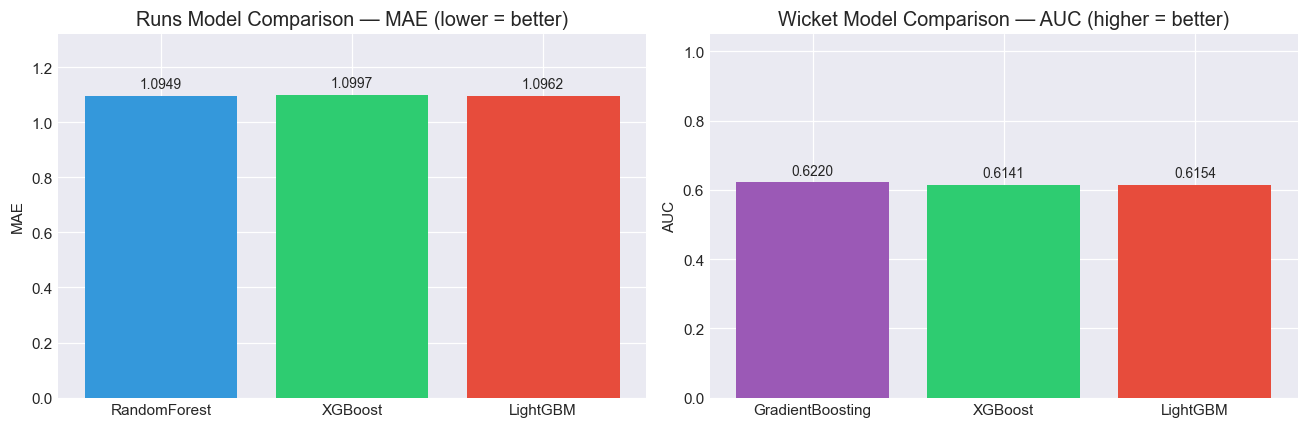

In [ ]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

names_r = list(runs_results.keys())
maes    = [runs_results[n]['mae'] for n in names_r]
bars1   = ax1.bar(names_r, maes, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax1.set_title('Runs Model Comparison — MAE (lower = better)')
ax1.set_ylabel('MAE')
ax1.set_ylim(0, max(maes) * 1.2)

names_w = list(wkt_results.keys())
aucs    = [wkt_results[n]['auc'] for n in names_w]
bars2   = ax2.bar(names_w, aucs, color=['#9b59b6', '#2ecc71', '#e74c3c'])
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
ax2.set_title('Wicket Model Comparison — AUC (higher = better)')
ax2.set_ylabel('AUC')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## 🎛️ Step 9 — Hyperparameter Tuning (Best Model)

In [ ]:
# Tune the best runs model with RandomizedSearchCV (quick, 20 iterations)
print(f'Tuning {best_runs_name} for runs…')

param_grid_runs = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10, 12],
        'min_samples_leaf': [10, 20, 30],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
    },
}

base_model_r = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost'     : xgb.XGBRegressor(random_state=42, verbosity=0),
    'LightGBM'    : lgb.LGBMRegressor(random_state=42, verbose=-1),
}[best_runs_name]

rs_runs = RandomizedSearchCV(
    base_model_r, param_grid_runs[best_runs_name],
    n_iter=20, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=0
)
rs_runs.fit(X_tr, yr_tr)
best_runs_model = rs_runs.best_estimator_

tuned_mae = mean_absolute_error(yr_te, best_runs_model.predict(X_te))
print(f'  Tuned {best_runs_name} MAE = {tuned_mae:.4f}  (was {runs_results[best_runs_name]["mae"]:.4f})')
print(f'  Best params: {rs_runs.best_params_}')


Tuning RandomForest for runs…
  Tuned RandomForest MAE = 1.0936  (was 1.0949)
  Best params: {'n_estimators': 300, 'min_samples_leaf': 30, 'max_depth': 6}


In [ ]:
# Tune the best wicket model
print(f'\nTuning {best_wkt_name} for wickets…')

param_grid_wkt = {
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
        'scale_pos_weight': [8, 10, 12],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
    },
}

base_model_w = {
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost'         : xgb.XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM'        : lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
}[best_wkt_name]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rs_wkt = RandomizedSearchCV(
    base_model_w, param_grid_wkt[best_wkt_name],
    n_iter=20, cv=skf, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
rs_wkt.fit(X_tr, yw_tr)
best_wkt_model = rs_wkt.best_estimator_

tuned_auc = roc_auc_score(yw_te, best_wkt_model.predict_proba(X_te)[:, 1])
print(f'  Tuned {best_wkt_name} AUC = {tuned_auc:.4f}  (was {wkt_results[best_wkt_name]["auc"]:.4f})')
print(f'  Best params: {rs_wkt.best_params_}')



Tuning GradientBoosting for wickets…
  Tuned GradientBoosting AUC = 0.6424  (was 0.6220)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


## 🔍 Step 10 — SHAP Explainability

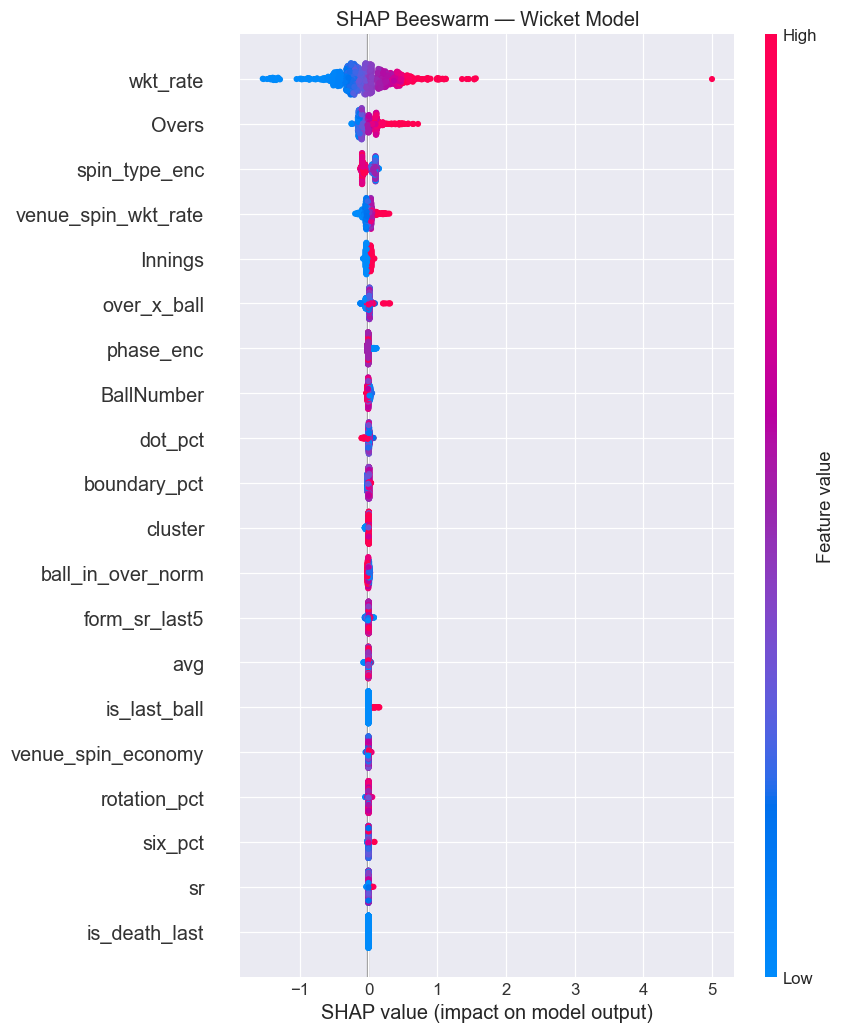

In [ ]:
# SHAP explainability for wicket model
explainer_wkt    = shap.TreeExplainer(best_wkt_model)
shap_values_wkt  = explainer_wkt.shap_values(X_te.iloc[:1000])

# Handle binary classifiers that return list of arrays
sv = shap_values_wkt[1] if isinstance(shap_values_wkt, list) else shap_values_wkt

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_te.iloc[:1000], feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Wicket Model')
plt.tight_layout()
plt.show()


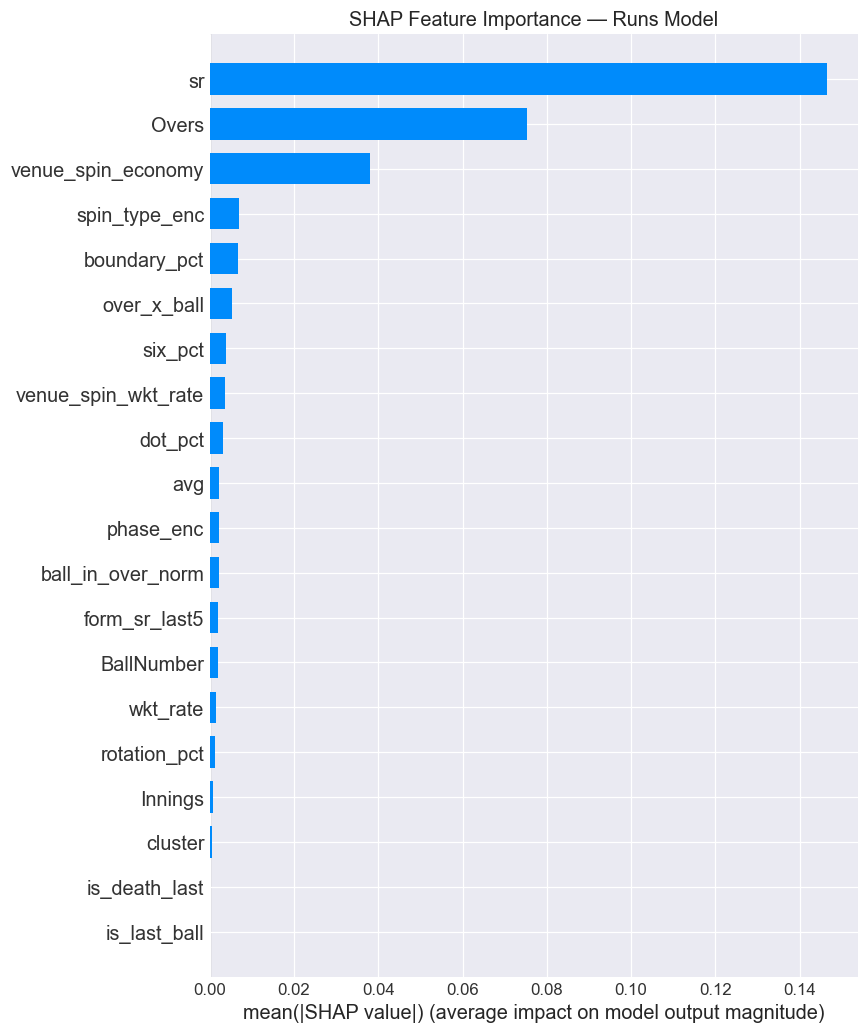

In [ ]:
# SHAP for runs model
explainer_runs   = shap.TreeExplainer(best_runs_model)
shap_values_runs = explainer_runs.shap_values(X_te.iloc[:1000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_runs, X_te.iloc[:1000],
                  feature_names=FEATURES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Runs Model')
plt.tight_layout()
plt.show()


## ✅ Step 11 — Validation

=== Wicket Model ===
              precision    recall  f1-score   support

     Not Out       0.96      1.00      0.98     11139
      Wicket       1.00      0.01      0.01       510

    accuracy                           0.96     11649
   macro avg       0.98      0.50      0.49     11649
weighted avg       0.96      0.96      0.94     11649



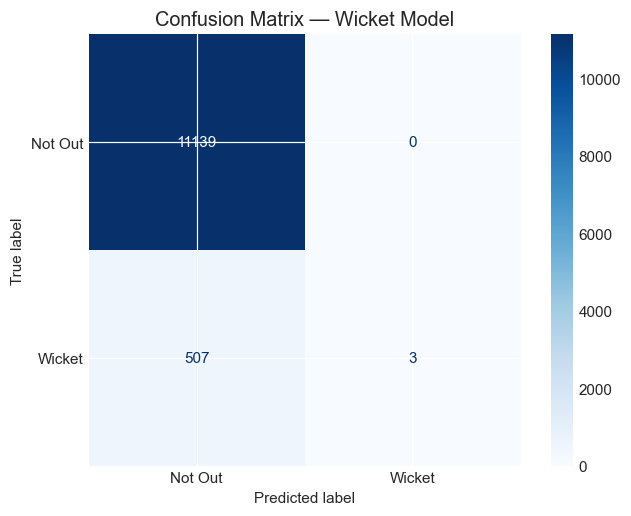

In [ ]:
# Wicket model classification report
print('=== Wicket Model ===')
preds_wkt = best_wkt_model.predict(X_te)
print(classification_report(yw_te, preds_wkt, target_names=['Not Out', 'Wicket']))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_wkt_model, X_te, yw_te,
                                       display_labels=['Not Out', 'Wicket'],
                                       cmap='Blues')
plt.title('Confusion Matrix — Wicket Model')
plt.tight_layout()
plt.show()


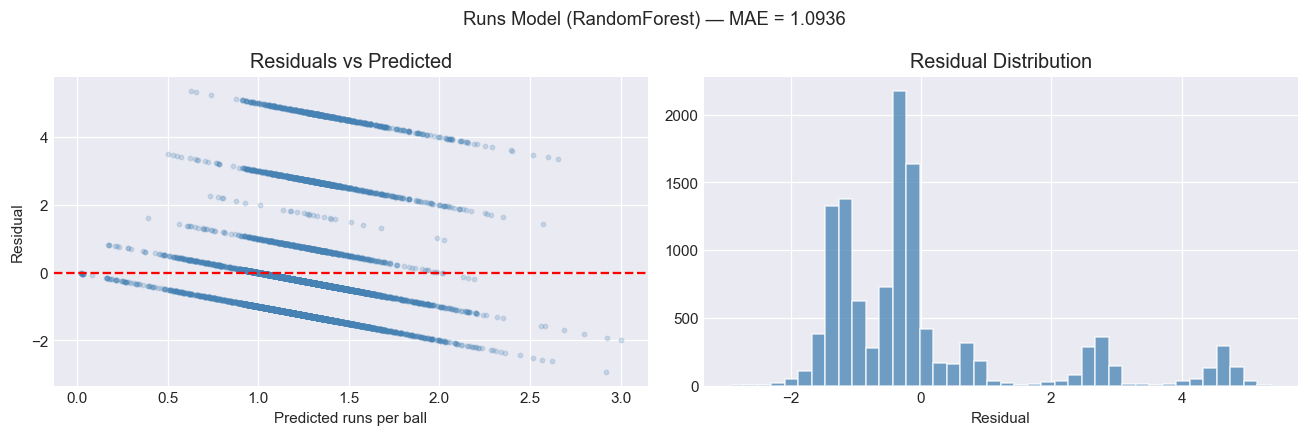

In [ ]:
# Runs model residual plot
preds_runs = best_runs_model.predict(X_te)
residuals  = yr_te.values - preds_runs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(preds_runs, residuals, alpha=0.2, s=8, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted runs per ball')
ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs Predicted')

ax2.hist(residuals, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax2.set_xlabel('Residual')
ax2.set_title('Residual Distribution')

plt.suptitle(f'Runs Model ({best_runs_name}) — MAE = {mean_absolute_error(yr_te, preds_runs):.4f}')
plt.tight_layout()
plt.show()


## 🔮 Step 12 — Prediction Function

In [ ]:
def predict_batter(batter_name, spin_type='right-arm offbreak',
                   phase='middle', innings=1, n_balls=12,
                   venue=None, verbose=True):
    """
    Predict batter performance vs a specific spin type.
    Uses per-spin-type batter stats (sr/avg/dot_pct etc) so each spin type
    gives a genuinely different prediction based on real historical data.
    Falls back to career stats if < MIN_BALLS_SPIN balls vs that spin type.
    """
    MIN_BALLS_SPIN   = 20
    MIN_BALLS_CAREER = 30

    # ── 1. Career lookup (existence check + cluster) ──────────────────────────
    brow_career = batter_feats[batter_feats['Batter'] == batter_name]
    if brow_career.empty:
        last = batter_name.split()[-1]
        brow_career = batter_feats[batter_feats['Batter'].str.contains(last, case=False, na=False)]
        if not brow_career.empty and verbose:
            print(f"\u26a0 '{batter_name}' matched to '{brow_career.iloc[0]['Batter']}' by last name")
    if brow_career.empty:
        if verbose: print(f"\u26d4 '{batter_name}' has no spin data.")
        return {'batter': batter_name, 'Status': 'NO DATA',
                'Message': 'No recorded balls vs spin.',
                'predicted_sr': None, 'predicted_runs': None,
                'expected_runs': None, 'dismissal_prob_pct': None,
                'dismiss_in_spell_pct': None, 'confidence': 'NONE'}

    matched_name = brow_career.iloc[0]['Batter']

    # ── 2. Per-spin-type lookup ────────────────────────────────────────────────
    brow_spin = batter_spin_feats[
        (batter_spin_feats['Batter']    == matched_name) &
        (batter_spin_feats['spin_type'] == spin_type)
    ]

    use_spin_specific = (
        not brow_spin.empty and
        int(brow_spin['total_balls'].values[0]) >= MIN_BALLS_SPIN
    )

    if use_spin_specific:
        brow         = brow_spin
        n_balls_hist = int(brow['total_balls'].values[0])
        data_source  = f'spin-specific ({spin_type})'
    else:
        brow         = brow_career
        n_balls_hist = int(brow['total_balls'].values[0])
        data_source  = 'career fallback'
        if verbose:
            if brow_spin.empty:
                print(f"\u26a0 No data vs '{spin_type}' \u2014 using career stats.")
            else:
                spin_b = int(brow_spin['total_balls'].values[0])
                print(f"\u26a0 Only {spin_b} balls vs '{spin_type}' (min {MIN_BALLS_SPIN}) \u2014 using career stats.")

    if n_balls_hist < MIN_BALLS_CAREER and not use_spin_specific:
        if verbose:
            print(f"\u26a0 Only {n_balls_hist} career balls vs spin \u2014 min {MIN_BALLS_CAREER} required.")
        return {'batter': batter_name, 'Status': 'INSUFFICIENT DATA',
                'Message': f'Only {n_balls_hist} balls vs spin (min {MIN_BALLS_CAREER}).',
                'predicted_sr': None, 'predicted_runs': None,
                'expected_runs': None, 'dismissal_prob_pct': None,
                'dismiss_in_spell_pct': None, 'confidence': f'TOO LOW ({n_balls_hist} balls)'}

    # ── 3. Confidence ──────────────────────────────────────────────────────────
    if   n_balls_hist >= 200: confidence = 'HIGH'
    elif n_balls_hist >= 100: confidence = 'MEDIUM'
    elif n_balls_hist >= 50:  confidence = 'LOW'
    else:                     confidence = 'VERY LOW'

    cluster_val = int(brow_career['cluster'].values[0]) if 'cluster' in brow_career.columns else 0
    if verbose:
        print(f"\U0001f4ca '{matched_name}' \u2014 {n_balls_hist} balls | {data_source} | "
              f"Confidence: {confidence} | Cluster: {cluster_val}")

    # ── 4. Encodings ───────────────────────────────────────────────────────────
    spin_enc  = int(le_spin.transform([spin_type])[0])  if spin_type in le_spin.classes_  else 0
    phase_enc = int(le_phase.transform([phase])[0])     if phase     in le_phase.classes_ else 1

    # ── 5. Venue ───────────────────────────────────────────────────────────────
    vrow  = venue_feats[venue_feats['venue'] == venue] if venue else pd.DataFrame()
    v_wkt = float(vrow['venue_spin_wkt_rate'].values[0]) if not vrow.empty else float(venue_feats['venue_spin_wkt_rate'].mean())
    v_eco = float(vrow['venue_spin_economy'].values[0])  if not vrow.empty else float(venue_feats['venue_spin_economy'].mean())

    # ── 6. Recent form ─────────────────────────────────────────────────────────
    form_row = form_feats[form_feats['Batter'] == matched_name]
    form_sr  = float(form_row['form_sr_last5'].values[0]) if not form_row.empty else float(brow['sr'].values[0])

    # ── 7. Feature vector ──────────────────────────────────────────────────────
    over_map = {'powerplay': 3, 'middle': 10, 'death': 17}
    over_num = over_map.get(phase.lower(), 10)
    ball_num = 3

    feat_vals = [
        over_num, ball_num, innings,
        spin_enc, phase_enc,
        ball_num / 6, 0, over_num * ball_num, int(over_num >= 17 and ball_num >= 5),
        float(brow['sr'].values[0]),            # spin-specific SR
        float(brow['avg'].values[0]),           # spin-specific avg
        float(brow['dot_pct'].values[0]),       # spin-specific dot%
        float(brow['boundary_pct'].values[0]),  # spin-specific boundary%
        float(brow['six_pct'].values[0]),       # spin-specific six%
        float(brow['wkt_rate'].values[0]),      # spin-specific wkt_rate
        float(brow['rotation_pct'].values[0]),  # spin-specific rotation%
        cluster_val,
        v_wkt, v_eco,
        form_sr,
    ]

    X_pred = pd.DataFrame([feat_vals], columns=FEATURES)

    # ── 8. Predict ─────────────────────────────────────────────────────────────
    pred_runs_pb   = max(0.0, float(best_runs_model.predict(X_pred)[0]))
    pred_dism_prob = float(best_wkt_model.predict_proba(X_pred)[0][1])

    pred_sr          = round(pred_runs_pb * 100, 1)
    pred_runs_total  = round(pred_runs_pb * n_balls, 1)
    dismissal_pct    = round(pred_dism_prob * 100, 2)
    dismiss_in_spell = round((1 - (1 - pred_dism_prob) ** n_balls) * 100, 1)
    expected_runs    = round(pred_runs_total * (1 - pred_dism_prob), 1)

    if verbose:
        print()
        print('\u2550' * 62)
        print(f'  \U0001f3cf {matched_name}')
        print(f'  vs {spin_type}  |  {phase}  |  inn {innings}  |  venue: {venue or "unknown"}')
        print(f'  Data: {data_source}  |  Historical SR vs this spin: {round(float(brow["sr"].values[0]), 1)}')
        print('\u2550' * 62)
        print(f'  Predicted Strike Rate     : {pred_sr}')
        print(f'  Predicted Runs ({n_balls} balls) : {pred_runs_total}')
        print(f'  Dismissal prob / ball     : {dismissal_pct}%')
        print(f'  Dismissal prob in spell   : {dismiss_in_spell}%')
        print(f'  \u2605 Expected Runs (adj)     : {expected_runs}')
        print(f'  Confidence                : {confidence}')
        print('\u2550' * 62)

    return {
        'batter'               : matched_name,
        'spin_type'            : spin_type,
        'phase'                : phase,
        'predicted_sr'         : pred_sr,
        'predicted_runs'       : pred_runs_total,
        'expected_runs'        : expected_runs,
        'dismissal_prob_pct'   : dismissal_pct,
        'dismiss_in_spell_pct' : dismiss_in_spell,
        'confidence'           : confidence,
        'data_source'          : data_source,
        'Status'               : 'OK',
    }


print('\u2705 predict_batter() ready \u2014 per-spin-type features')

# ── Sanity check: same batter, 3 spin types should give different SR ──────────
print('\n\u2500\u2500 Sanity check \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
for st in ['right-arm offbreak', 'legbreak googly', 'slow left-arm orthodox']:
    r = predict_batter('RG Sharma', spin_type=st, phase='middle', verbose=False)
    if r['Status'] == 'OK':
        print(f"  vs {st:<28}  SR={r['predicted_sr']:>6}  Wkt%={r['dismissal_prob_pct']:>5}%  [{r['data_source']}]")
    else:
        print(f"  vs {st:<28}  {r['Status']}")


✅ predict_batter() ready


## 🎲 Step 13 — Monte Carlo Simulation


🎲 Monte Carlo — RG Sharma vs legbreak (middle, 1,000 simulations)
   Mean                : 9.8
   Median              : 10.0
   P10 (worst 10%)     : 1.0
   P90 (best  10%)     : 19.0
   P(≥15 runs)         : 25.2%
   P(dismissed duck)   : 9.1%


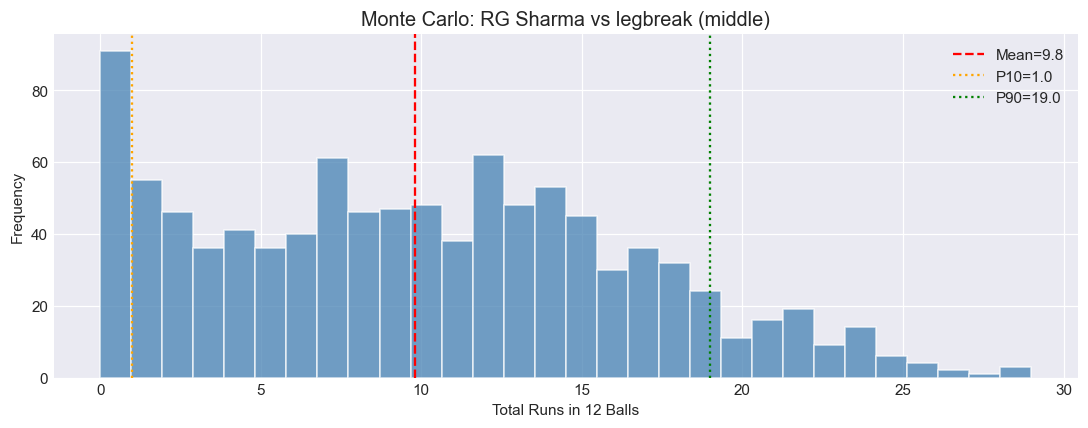

In [ ]:
def monte_carlo_simulate(batter_name, spin_type, phase, innings=1,
                          n_balls=12, n_simulations=1000, venue=None):
    """
    Simulate n_simulations possible innings for a batter against spin.
    On each ball: dismissed with probability pred_dism_prob, else scores
    runs sampled from their historical ball-level distribution.
    Returns array of total runs simulated.
    """
    pred = predict_batter(batter_name, spin_type, phase, innings,
                          n_balls, venue, verbose=False)

    # ── Guard: bail out cleanly if batter has no/insufficient data ────────────
    if pred.get('Status') in ('NO DATA', 'INSUFFICIENT DATA'):
        print(f"\u26a0  Cannot simulate '{batter_name}': {pred.get('Message', pred.get('Status'))}")
        return np.array([])

    dism_prob = pred['dismissal_prob_pct'] / 100

    # Use batter-specific ball distribution; fall back to full spin dataset
    batter_balls = spin[spin['Batter'] == batter_name]['BatsmanRun'].values
    if len(batter_balls) < 20:
        batter_balls = spin['BatsmanRun'].values

    np.random.seed(42)
    totals = []
    for _ in range(n_simulations):
        total = 0
        for _ in range(n_balls):
            if np.random.random() < dism_prob:
                break
            total += int(np.random.choice(batter_balls))
        totals.append(total)
    totals = np.array(totals)

    print(f'\n\U0001f3b2 Monte Carlo \u2014 {batter_name} vs {spin_type} ({phase}, {n_simulations:,} simulations)')
    print(f'   Mean                : {totals.mean():.1f}')
    print(f'   Median              : {np.median(totals):.1f}')
    print(f'   P10 (worst 10%)     : {np.percentile(totals,10):.1f}')
    print(f'   P90 (best  10%)     : {np.percentile(totals,90):.1f}')
    print(f'   P(\u226515 runs)         : {(totals>=15).mean()*100:.1f}%')
    print(f'   P(dismissed duck)   : {(totals==0).mean()*100:.1f}%')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(totals, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(totals.mean(),            color='red',    linestyle='--', label=f'Mean={totals.mean():.1f}')
    ax.axvline(np.percentile(totals,10), color='orange', linestyle=':',  label=f'P10={np.percentile(totals,10):.1f}')
    ax.axvline(np.percentile(totals,90), color='green',  linestyle=':',  label=f'P90={np.percentile(totals,90):.1f}')
    ax.set_xlabel(f'Total Runs in {n_balls} Balls')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Monte Carlo: {batter_name} vs {spin_type} ({phase})')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return totals


# ── Example ────────────────────────────────────────────────────────────────────
_ = monte_carlo_simulate('RG Sharma', 'legbreak', phase='middle', n_balls=12)


## 🏟️ Step 14 — Full Match Prediction

In [ ]:
# ── Check 1: Which XI batters are missing from batter_features ──
xi = ['DP Conway', 'M Theekshana', 'DS Kulkarni', 'MJ Santner', 
      'SB Dube', 'RA Jadeja']  # your full XI here

missing_bf = [b for b in xi if batter_feats[batter_feats['Batter'] == b].empty]
print("❌ Missing from batter_features.csv:", missing_bf)

# ── Check 2: Venue name exact match ──
venue = 'Wankhede Stadium'
match = venue_feats[venue_feats['venue'].str.lower() == venue.lower()]
print("❌ Venue match:" if match.empty else "✅ Venue found:", venue)
print("Available venues:", venue_feats['venue'].tolist())

# ── Check 3: Which batters missing from form_features ──
missing_ff = [b for b in xi if form_feats[form_feats['Batter'] == b].empty]
print("❌ Missing from form_features.csv:", missing_ff)

❌ Missing from batter_features.csv: ['SB Dube']
✅ Venue found: Wankhede Stadium
Available venues: ['Arun Jaitley Stadium', 'Barabati Stadium', 'Barsapara Cricket Stadium', 'Brabourne Stadium', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Ekana Cricket Stadium', 'Feroz Shah Kotla', 'Green Park', 'Himachal Pradesh Cricket Association Stadium', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Maharashtra Cricket Association Stadium', 'Narendra Modi Stadium', 'Nehru Stadium', 'New Chandigarh Stadium', 'New Wanderers Stadium', 'OUTsurance Oval', 'Punjab Cricket Association IS Bindra Stadium', 'Rajiv Gandhi International Stadium', 'Saurashtra Cricket Association Stadium', 'Sawai Mansingh Stadium', 'Shaheed Veer Narayan Singh 

In [ ]:
def predict_match_vs_spin(batting_xi, bowling_team_xi, venue, phase, n_balls=12):
    """
    Predict all batters in batting_xi against the spin bowlers in bowling_team_xi.
    Skips batters with no / insufficient spin data and reports them separately.
    Returns a DataFrame sorted by expected_runs descending.
    """
    # Identify spin bowlers in bowling team
    spin_bowlers_in_team = [
        (b, spin_map[b]) for b in bowling_team_xi if b in spin_map
    ]

    if not spin_bowlers_in_team:
        print('\u26a0 No spin bowlers found in bowling XI')
        return pd.DataFrame()

    print('Spin bowlers identified in bowling team:')
    for b, t in spin_bowlers_in_team:
        print(f'  {b} \u2014 {t}')
    print()

    # Use primary spin type (most common in the XI)
    from collections import Counter
    primary_spin = Counter(t for _, t in spin_bowlers_in_team).most_common(1)[0][0]

    results = []
    skipped = []

    for batter in batting_xi:
        r = predict_batter(batter, spin_type=primary_spin,
                           phase=phase, n_balls=n_balls,
                           venue=venue, verbose=False)

        if r.get('Status') in ('NO DATA', 'INSUFFICIENT DATA'):
            skipped.append(r)
            print(f"\u23ed  Skipped: {batter} \u2014 {r.get('Message', r.get('Status'))}")
            continue

        results.append(r)

    if skipped:
        print(f"\n\u26a0  {len(skipped)} batter(s) skipped due to insufficient spin data:")
        for s in skipped:
            print(f"   \u2022 {s['batter']}: {s.get('Message', '')}")

    if not results:
        print('\u274c No batters had enough spin data to predict.')
        return pd.DataFrame()

    df = pd.DataFrame(results)[[
        'batter', 'predicted_sr', 'predicted_runs', 'expected_runs',
        'dismissal_prob_pct', 'dismiss_in_spell_pct', 'confidence'
    ]].rename(columns={
        'batter'               : 'Batter',
        'predicted_sr'         : 'Pred SR',
        'predicted_runs'       : 'Pred Runs',
        'expected_runs'        : 'Expected Runs',
        'dismissal_prob_pct'   : 'Dismissal %',
        'dismiss_in_spell_pct' : 'Dismiss in Spell %',
        'confidence'           : 'Confidence',
    }).sort_values('Expected Runs', ascending=False).reset_index(drop=True)

    return df


In [ ]:
# ── Define your match and run the prediction ─────────────────────────────────
# Edit these two XIs and the venue/phase to match the fixture you want to predict

match = {
    'team1' : 'Mumbai Indians',        # batting team
    'team2' : 'Chennai Super Kings',   # bowling team
    'venue' : 'Wankhede Stadium',
    'phase' : 'middle',                # 'powerplay' | 'middle' | 'death'
}

# Replace with the actual playing XI names (must match names in batter_features.csv)
batting_xi = [
    'RG Sharma', 'IR Pandya', 'SA Yadav', 'TM Head',
    'N Tilak Varma', 'AT Rayudu', 'KA Pollard',
    'KH Pandya', 'JJ Bumrah', 'B Kumar', 'TG Southee',
]

bowling_xi = [
    'RA Jadeja', 'AS Rajpoot', 'MS Pathirana',
    'Imran Tahir', 'DL Chahar', 'SN Thakur',
]

# ── Run the full match prediction ─────────────────────────────────────────────
result_df = predict_match_vs_spin(
    batting_xi      = batting_xi,
    bowling_team_xi = bowling_xi,
    venue           = match['venue'],
    phase           = match['phase'],
    n_balls         = 12,
)

if not result_df.empty:
    print()
    print(result_df.to_string(index=False))


Spin bowlers identified in bowling team:
  RA Jadeja — slow left-arm orthodox

⏭  Skipped: JJ Bumrah — Only 10 balls faced vs spin (minimum 30 required).
⏭  Skipped: TG Southee — Only 4 balls faced vs spin (minimum 30 required).

⚠  2 batter(s) skipped due to insufficient spin data:
   • JJ Bumrah: Only 10 balls faced vs spin (minimum 30 required).
   • TG Southee: Only 4 balls faced vs spin (minimum 30 required).

       Batter  Pred SR  Pred Runs  Expected Runs  Dismissal %  Dismiss in Spell % Confidence
      TM Head    154.3       18.5           17.7         4.55                42.8     MEDIUM
N Tilak Varma    140.0       16.8           16.5         1.93                20.9       HIGH
   KA Pollard    142.2       17.1           16.4         4.13                39.7       HIGH
     SA Yadav    135.0       16.2           15.8         2.43                25.5       HIGH
    IR Pandya    132.3       15.9           15.4         3.12                31.7       HIGH
    RG Sharma    111.6 

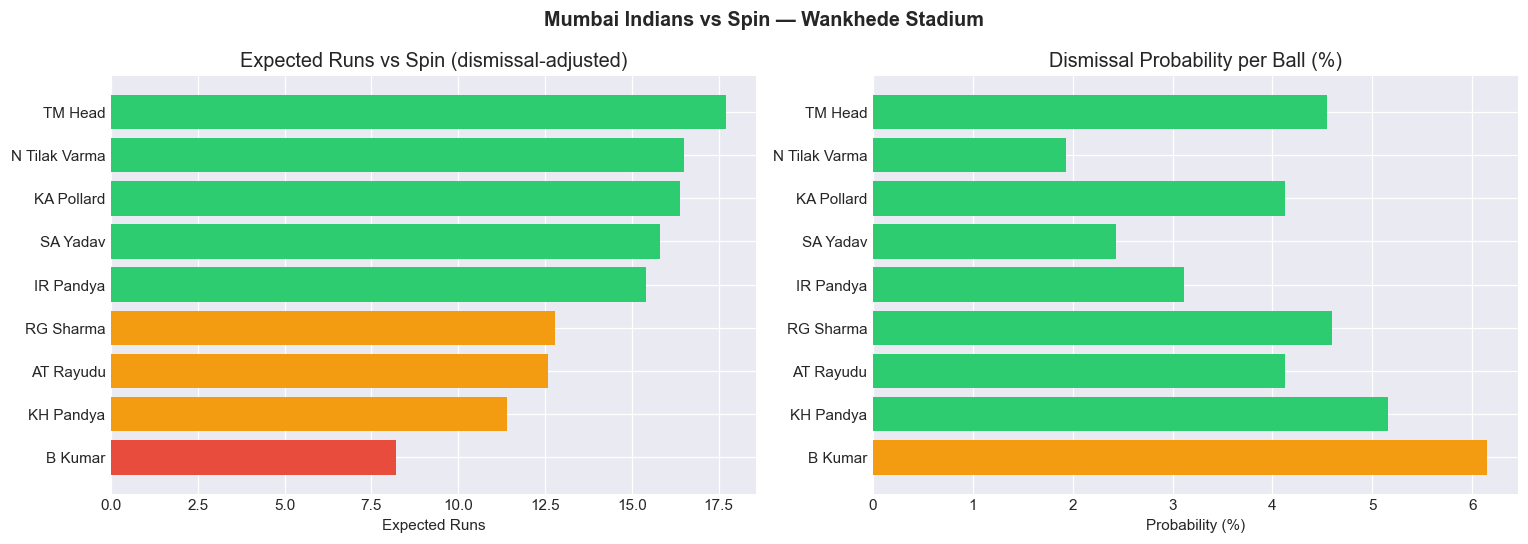

In [ ]:
# Visualise match prediction results
if not result_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors_r = ['#2ecc71' if x > 120 else '#f39c12' if x > 90 else '#e74c3c'
                for x in result_df['Pred SR']]
    ax1.barh(result_df['Batter'], result_df['Expected Runs'], color=colors_r)
    ax1.set_title('Expected Runs vs Spin (dismissal-adjusted)')
    ax1.set_xlabel('Expected Runs')
    ax1.invert_yaxis()

    # Column is 'Dismissal %' (probability per ball × 100)
    colors_d = ['#2ecc71' if x < 6 else '#f39c12' if x < 10 else '#e74c3c'
                for x in result_df['Dismissal %']]
    ax2.barh(result_df['Batter'], result_df['Dismissal %'], color=colors_d)
    ax2.set_title('Dismissal Probability per Ball (%)')
    ax2.set_xlabel('Probability (%)')
    ax2.invert_yaxis()

    plt.suptitle(
        f"{match.get('team1','Batting XI')} vs Spin — {match.get('venue','')}",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
else:
    print('⚠  No results to visualise — check that batter names match batter_features.csv')


## 💾 Step 15 — Save All Artefacts

In [ ]:
# ── Models & encoders ────────────────────────────────────────────────────────
joblib.dump(best_runs_model, 'model_runs.pkl')
joblib.dump(best_wkt_model,  'model_wicket.pkl')
joblib.dump(le_spin,         'encoder_spin.pkl')
joblib.dump(le_phase,        'encoder_phase.pkl')
joblib.dump(scaler,          'scaler_cluster.pkl')
joblib.dump(kmeans,          'model_kmeans.pkl')

# ── CSVs ─────────────────────────────────────────────────────────────────────
batter_feats.to_csv('batter_features.csv',           index=False)  # career (all spin)
batter_spin_feats.to_csv('batter_spin_features.csv', index=False)  # per spin type <- NEW
venue_feats.to_csv('venue_features.csv',             index=False)
form_feats.to_csv('form_features.csv',               index=False)

# ── Batter vs spin breakdown (used by /player-stats endpoint) ─────────────────
bvs = spin.groupby(['Batter', 'spin_type']).agg(
    balls      = ('BatsmanRun', 'count'),
    runs       = ('BatsmanRun', 'sum'),
    dismissals = ('IsWicketDelivery', 'sum'),
).reset_index()
bvs['sr']  = (bvs['runs'] / bvs['balls'] * 100).round(1)
bvs['avg'] = (bvs['runs'] / bvs['dismissals'].replace(0, np.nan)).fillna(bvs['runs']).round(1)
bvs.rename(columns={'spin_type': 'bowler_spin_type'}, inplace=True)
bvs.to_csv('batter_vs_spin_stats.csv', index=False)

print('\u2705 All artefacts saved:')
for f in ['model_runs.pkl', 'model_wicket.pkl', 'encoder_spin.pkl',
          'encoder_phase.pkl', 'model_kmeans.pkl', 'scaler_cluster.pkl',
          'batter_features.csv', 'batter_spin_features.csv',
          'venue_features.csv', 'form_features.csv', 'batter_vs_spin_stats.csv']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f'  {f:<40} {size/1024:>7.1f} KB')


✅ All artefacts saved:
  model_runs.pkl                       2328.5 KB
  model_wicket.pkl                      139.8 KB
  encoder_spin.pkl                        0.6 KB
  encoder_phase.pkl                       0.5 KB
  model_kmeans.pkl                        1.7 KB
  scaler_cluster.pkl                      1.0 KB
  batter_features.csv                    61.4 KB
  venue_features.csv                      2.4 KB
  form_features.csv                      12.3 KB
  batter_vs_spin_stats.csv               73.8 KB
